#Librerias

In [109]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

# Inciso 1

[ 0  0  1  0  0  5  9 15 13 17 16 11  6  2  4  1  0  0  0]


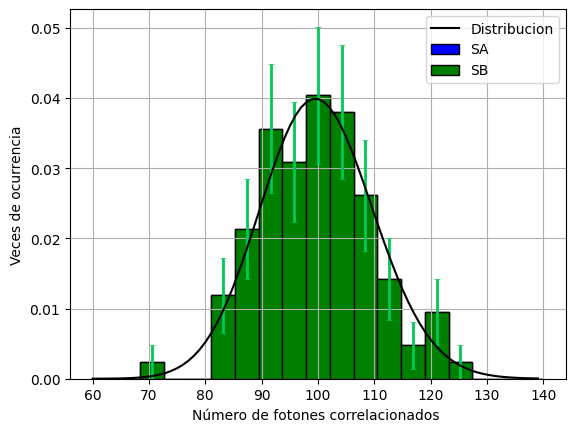

In [110]:
mu1=100
SA = poisson.rvs(mu1, size=100)
SB=SA
#Comparativa teorica
x=np.arange(60,140,1)
Poisson=poisson.pmf(x, mu1)
#Para ver esta distribucion
bins_1 = np.linspace(60, 140, 20)
w_1 = np.diff(bins_1) #ANCHO DE LOS BINS
y_density_1,Bins_1 = np.histogram(SA, bins=bins_1, density=True)

y_density_5 = np.histogram(SA, bins=bins_1)[0]
sigma_histograma=np.sqrt(y_density_5)
errores_normalizados=sigma_histograma/(sum(y_density_5)*w_1)

plt.bar(Bins_1[:-1], y_density_1,yerr=errores_normalizados,width=w_1, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='SA')
plt.bar(Bins_1[:-1], y_density_1,width=w_1, color='green',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='SB')
plt.plot(x,Poisson,color='black',label='Distribucion')
plt.xlabel('Número de fotones correlacionados ')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()
print(y_density_5)

# Inciso 2

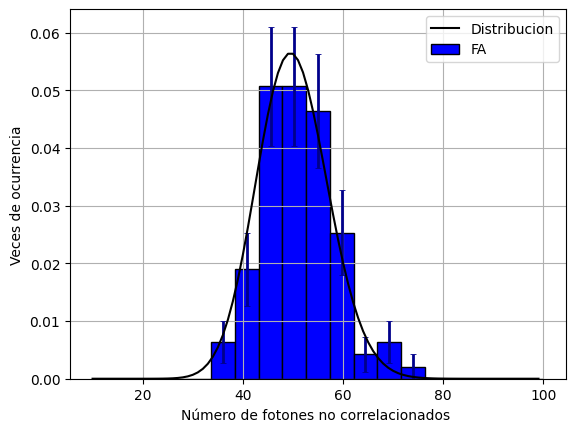

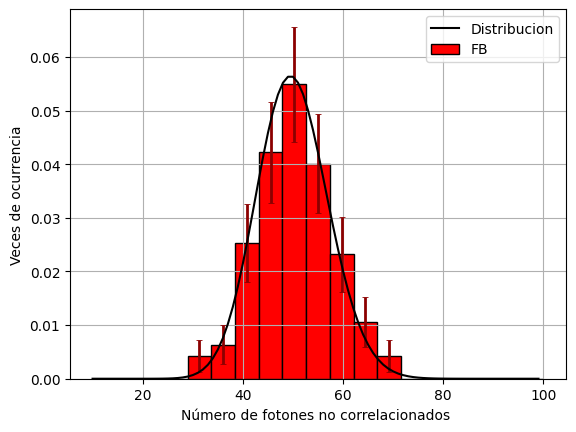

In [111]:
mu2=50
FA = poisson.rvs(mu2, size=100)
FB = poisson.rvs(mu2, size=100)

#Comparativa teorica
x=np.arange(10,100,1)
Poisson=poisson.pmf(x, mu2)
#Para ver esta distribucion
bins_1 = np.linspace(10, 100, 20)
w_1 = np.diff(bins_1) #ANCHO DE LOS BINS
y_density_1,Bins_1 = np.histogram(FA, bins=bins_1, density=True)
y_density_2,Bins_2 = np.histogram(FB, bins=bins_1, density=True)

y_density_6 = np.histogram(FA, bins=bins_1)[0]
sigma_histograma_6=np.sqrt(y_density_6)
errores_normalizados_6=sigma_histograma_6/(sum(y_density_6)*w_1)

y_density_7 = np.histogram(FB, bins=bins_1)[0]
sigma_histograma_7=np.sqrt(y_density_7)
errores_normalizados_7=sigma_histograma_7/(sum(y_density_7)*w_1)

plt.bar(Bins_1[:-1], y_density_1,yerr=errores_normalizados_6,width=w_1, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00008B', lw=2, capsize=2, capthick=0.6),label='FA')
plt.plot(x,Poisson,color='black',label='Distribucion')
plt.xlabel('Número de fotones no correlacionados ')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()
plt.show()
plt.bar(Bins_2[:-1], y_density_2,yerr=errores_normalizados_7,width=w_1, color='red',align='edge', ec='k',error_kw=dict(ecolor='#8B0000', lw=2, capsize=2, capthick=0.6),label='FB')
plt.plot(x,Poisson,color='black',label='Distribucion')
plt.xlabel('Número de fotones no correlacionados ')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()

#Inciso 3

In [112]:
MA=SA+FA
MB=SB+FB

#SUMA DE POISSON ES POSSION CON LA SUMA DE PRAMETROS MA ES POISSON CON MU1+MU2, MB ES POISSON CON LA MISMA
MA_bar=(sum(MA))/len(MA)
MB_bar=(sum(MB))/len(MB)

n=len(MA)
MA_desv=MA-MA_bar
MB_desv=MB-MB_bar

MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))

MA_sig=np.sqrt(MA_var)
MB_sig=np.sqrt(MB_var)
cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
print('La covarianza de estas listas x e y es',cov_bien)

La covarianza de estas listas x e y es 118.50505050505046


In [113]:
#covariance = np.cov(MA, MB)
#print(covariance[0][1])
#print(covariance)

correlation=cov_bien/(MA_sig*MB_sig)
print(correlation)

0.7256865212038772


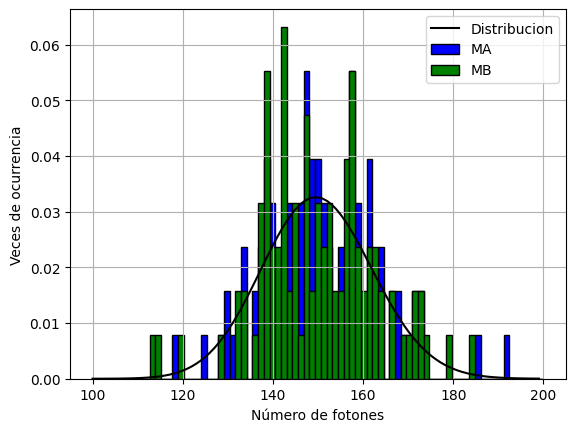

In [114]:
#Comparacion de los ploteos
x=np.arange(100,200,1)
Poisson=poisson.pmf(x, mu2+mu1)
#Para ver esta distribucion
bins_1 = np.linspace(100, 200, 80)
w_1 = np.diff(bins_1) #ANCHO DE LOS BINS
y_density_1,Bins_1 = np.histogram(MA, bins=bins_1, density=True)
y_density_2,Bins_2 = np.histogram(MB, bins=bins_1, density=True)

plt.bar(Bins_1[:-1], y_density_1,width=w_1, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='MA')
plt.bar(Bins_2[:-1], y_density_2,width=w_1, color='green',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='MB')
plt.plot(x,Poisson,color='black',label='Distribucion')
plt.xlabel('Número de fotones')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()

Tienen covarianza xq puedo despejar SA en funcion de las otras cosas, entonces es sensible a las variaciones de las cantidades xq obtengo una en funcion de la otra

#Inciso 4

GENERO INDEPNEIDNETES SA Y SB PARA QUE NO ESTEN CORRELACINADOS, LA CUAL SERIA MI H0

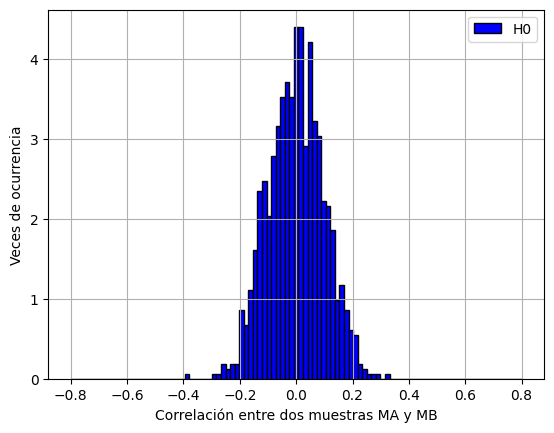

In [115]:
#Todo junto, con variables no correlacionadas HO  ESTE SERIA EL INCISO 3
SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov=[]
N=1000
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB = poisson.rvs(mu1, size=100)
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  lista_cov.append(correlation)

bins = np.linspace(-0.8, 0.8, 100)
w = np.diff(bins) #ANCHO DE LOS BINS
y_density_HO,Bins = np.histogram(lista_cov, bins=bins, density=True)

sigma_histograma=np.sqrt(y_density_HO)
errores_normalizados=sigma_histograma/(sum(y_density_HO))


plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge' , ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()

0.06971800081875325


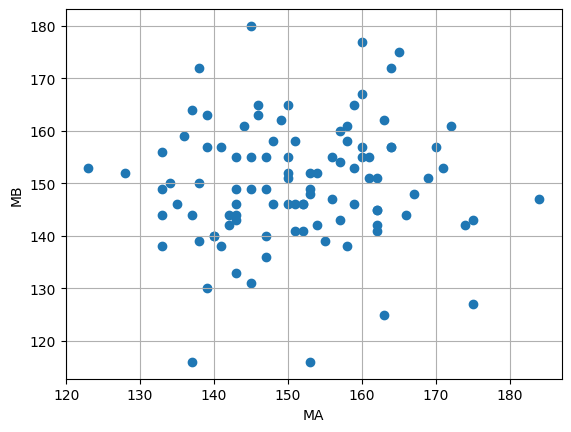

-0.018887142084648853


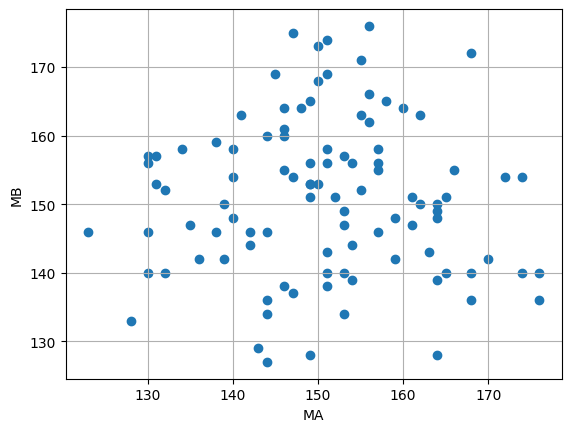

0.03373811855785187


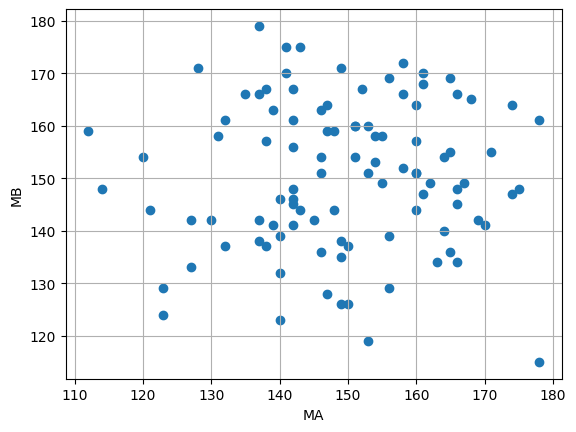

0.05609111953874835


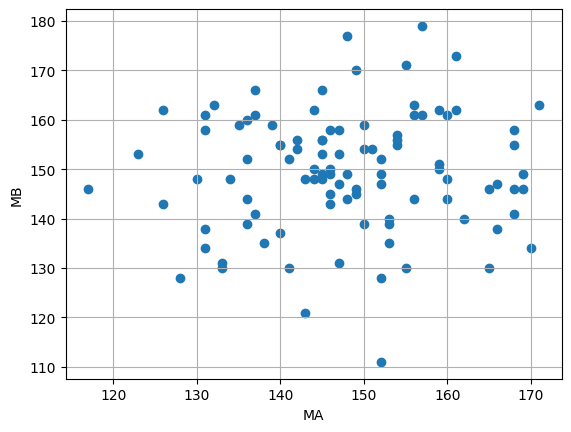

0.04353094889648634


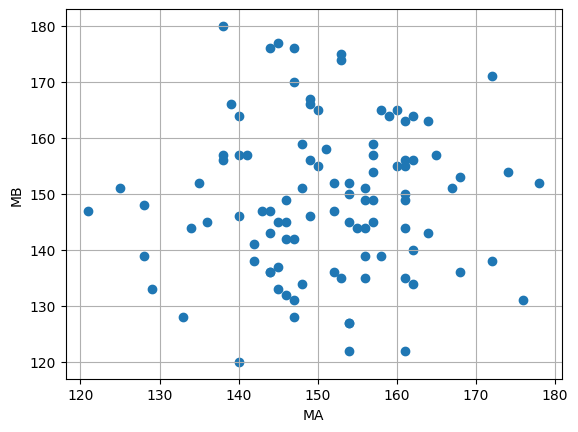

-0.103554941111389


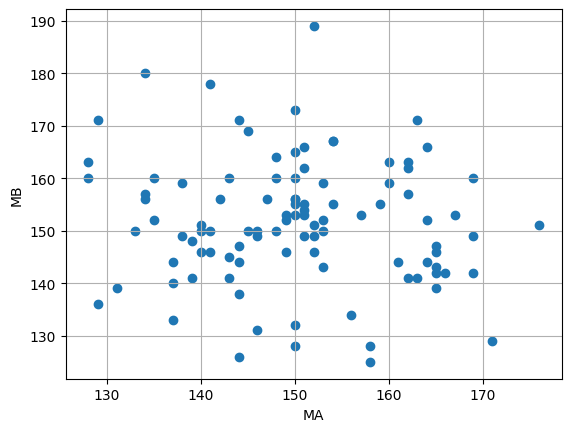

0.16801846355160147


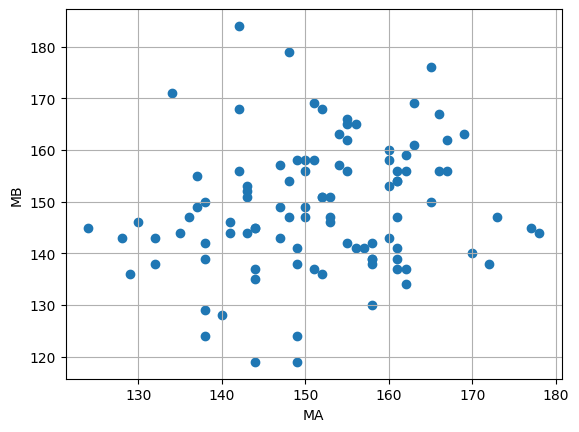

-0.0807627284368516


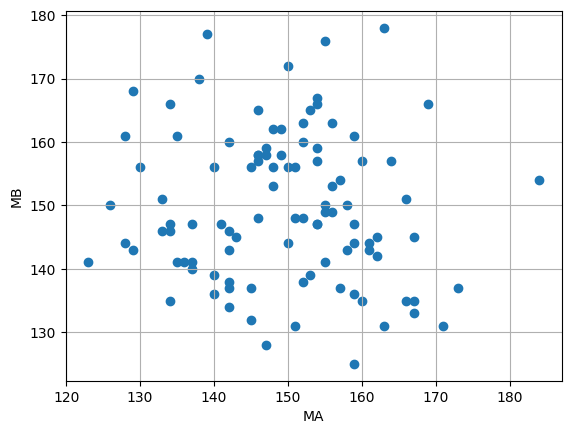

-0.005100633878396782


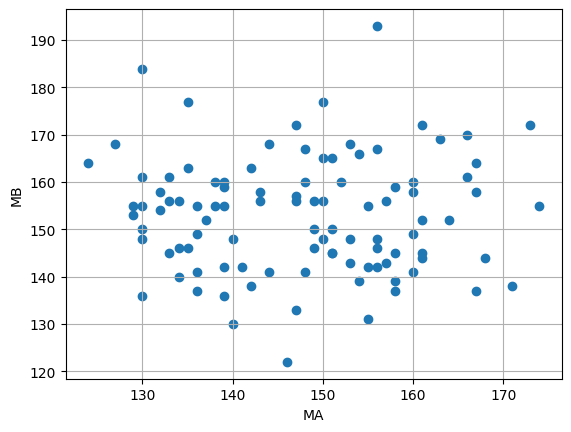

0.186459149651591


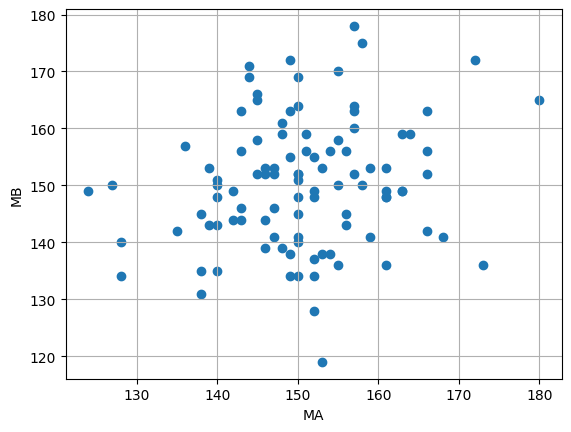

0.06284672024527366


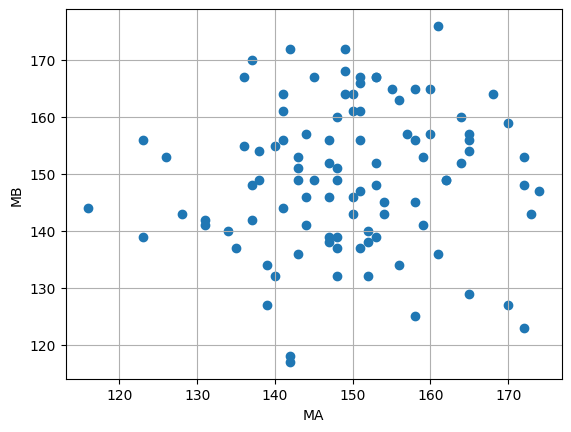

0.18801876651569557


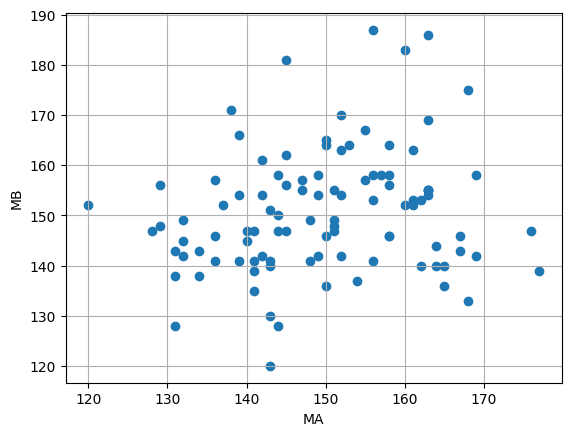

0.1285547269190518


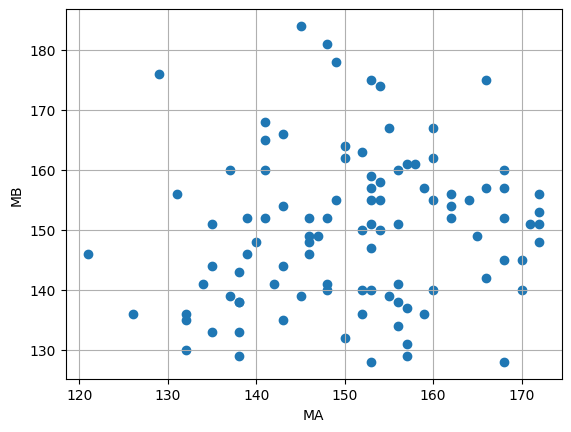

-0.07122594214427017


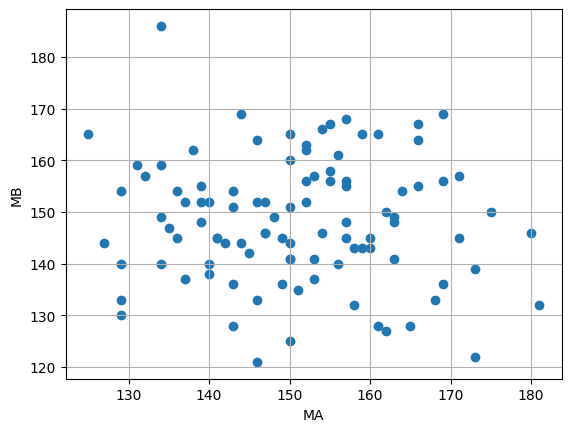

0.010372019366956602


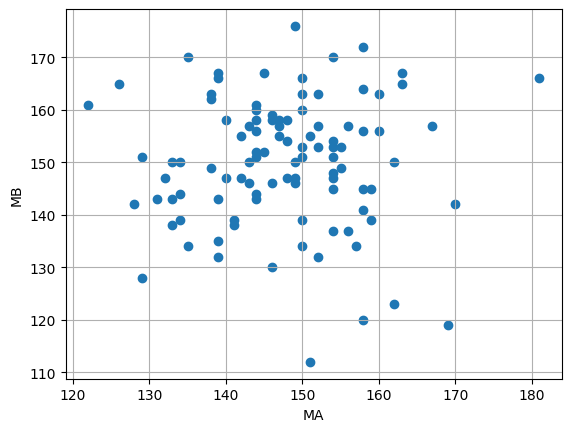

In [116]:
#PLOTEO DE LAS CORRELACIONES
#Todo junto, con variables no correlacionadas HO  ESTE SERIA EL INCISO 3
SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov=[]
N=15

for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB = poisson.rvs(mu1, size=100)
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  lista_cov.append(correlation)

  plt.figure()
  plt.scatter(MA,MB)
  print((np.cov(MA, MB)[0][1])/(MA_sig*MB_sig))
  plt.xlabel('MA')
  plt.ylabel('MB')
  plt.grid()
  plt.show()

Claro que va a estar cerrada xq el valor esperado es q no esten correlacionadas

#Inciso 5

In [117]:
lista=y_density_HO*w
valor_especifico=0.05

def sumar_hasta_valor_izquierda(lista, valor_especifico): #Funcion que me permite saber los valores de rechazo IZQ
    suma = 0
    for elemento in lista:
        if suma + elemento > valor_especifico:
            break
        suma += elemento
    Corte_izquierda=np.where(lista == elemento)[0]
    return suma,Corte_izquierda[0]

def sumar_hasta_valor_derecha(lista, valor_especifico): #Funcion que me permite saber los valores de rechazo IZQ
    suma = 0
    for elemento in lista[::-1]:
        if suma + elemento > valor_especifico:
            break
        suma += elemento
    Corte_derecha=np.where(lista == elemento)[0]
    return suma,Corte_derecha[0]

print(sumar_hasta_valor_derecha(lista, valor_especifico))
#print(sumar_hasta_valor_izquierda(lista, valor_especifico))
print(Bins[sumar_hasta_valor_derecha(lista, valor_especifico)[1]])



(0.042, 59)
0.15353535353535352


In [118]:
y_density_fuera_izquierda = y_density_HO[:sumar_hasta_valor_izquierda(lista, valor_especifico)[1]] #Cortando hasta el numero de rechazo
w_fuera_izquierda=w[:len(y_density_fuera_izquierda)]
Bins_fuera_izquierda=Bins[:len(y_density_fuera_izquierda)+1]

nuevo_array = y_density_HO[::-1]
Corte_invertido=len(nuevo_array)-sumar_hasta_valor_derecha(lista, valor_especifico)[1]
nuevo_array=nuevo_array[:Corte_invertido]
y_density_fuera_derecha=nuevo_array[::-1]

w_fuera_derecha=w[:len(y_density_fuera_derecha)]

nuevo_array = Bins[::-1]
Corte_invertido=len(nuevo_array)-(sumar_hasta_valor_derecha(lista, valor_especifico)[1])
nuevo_array=nuevo_array[:Corte_invertido]
Bins_fuera_derecha=nuevo_array[::-1]
#print(Bins_fuera_derecha[0])

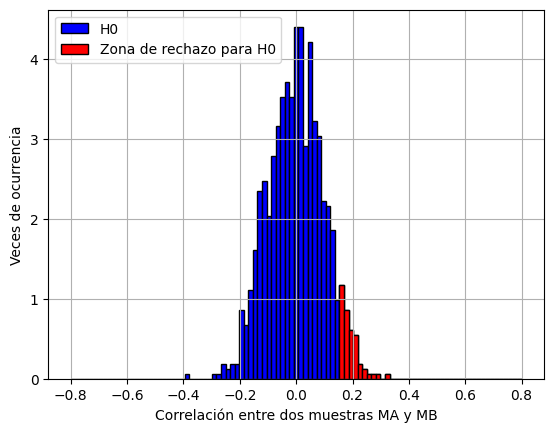

In [119]:
#ZONAS DE RECHAZO
plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge' , ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
#plt.bar(Bins_fuera_izquierda[:-1], y_density_fuera_izquierda,width=w_fuera_izquierda, color='red',align='edge',label='Datos de cada iteracion de y')
plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='Zona de rechazo para H0')
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()

AVISO: ES POSIBLE QUE EL CODIGO EJECUTE MAL SI LA MAYOR PARTE ES ROJA. DE SER ASI EJECUTAR DE VUELTA EL CODIGO HASTA QUE SALGA LA MAYOR PARTE EN AZUL Y EN ROJO LA ZONA DE RECHAZO.

#Inciso 6

In [120]:
#Todo junto CORRELACIONADOOOO
SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov_correlacionada=[]
N=1000
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB=SA
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  lista_cov_correlacionada.append(correlation)

bins_correlacionados = np.linspace(-0.8, 0.8, 100)
w = np.diff(bins_correlacionados) #ANCHO DE LOS BINS
y_density_correlacionada,Bins_correlacionados = np.histogram(lista_cov_correlacionada, bins=bins, density=True)

Text(0, 0.5, 'Veces de ocurrencia')

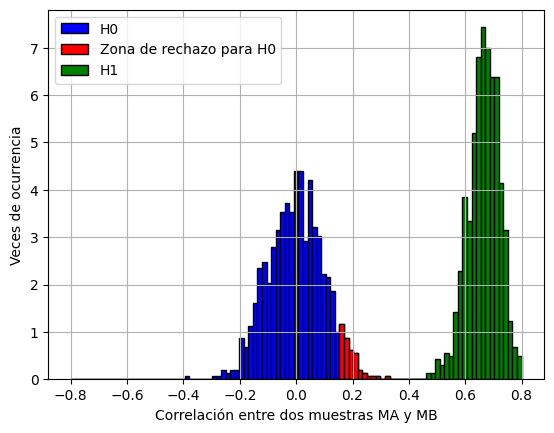

In [121]:
plt.grid()
plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
#plt.bar(Bins_fuera_izquierda[:-1], y_density_fuera_izquierda,width=w_fuera_izquierda, color='red',align='edge',label='Datos de cada iteracion de y')
plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='Zona de rechazo para H0')
plt.bar(Bins_correlacionados[:-1], y_density_correlacionada,width=w, color='green',align='edge' , ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H1') #
plt.legend()
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')

In [122]:
limite_inferior = Bins[sumar_hasta_valor_derecha(lista, valor_especifico)[1]]
limite_superior = 1

indice_inferior = np.searchsorted(Bins, limite_inferior)
indice_superior = np.searchsorted(Bins, limite_superior)

#area_rechazada = np.sum(y_density_fuera_derecha* np.diff(Bins_fuera_derecha))
area_correlacionada = np.sum(y_density_correlacionada[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])

print('El power, es decir 1 - beta es',area_correlacionada,'Es decir que beta es',1-area_correlacionada)
print('El error tipo 1',sumar_hasta_valor_derecha(lista, valor_especifico)[0])

El power, es decir 1 - beta es 1.0 Es decir que beta es 0.0
El error tipo 1 0.042


#Inciso 7

Solo plotearemos entonces nuevas H1, sobre las cuales variaremos mu2

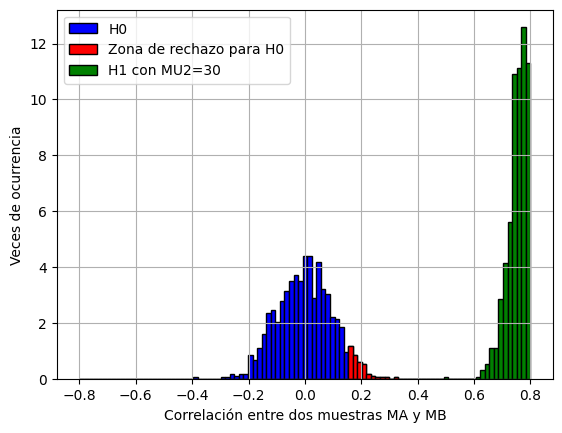

Para H1 con MU2=30, el power es  1.0 .Es decir que beta es 0.0


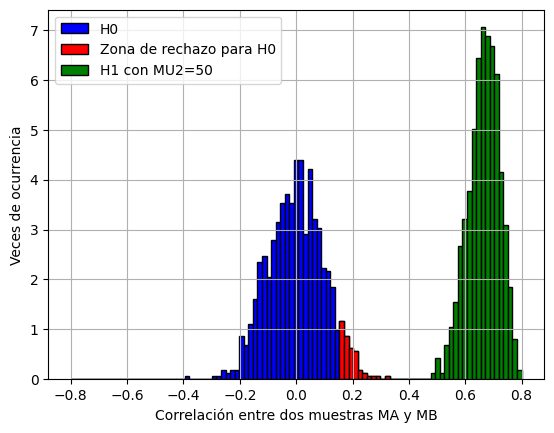

Para H1 con MU2=50, el power es  1.0 .Es decir que beta es 0.0


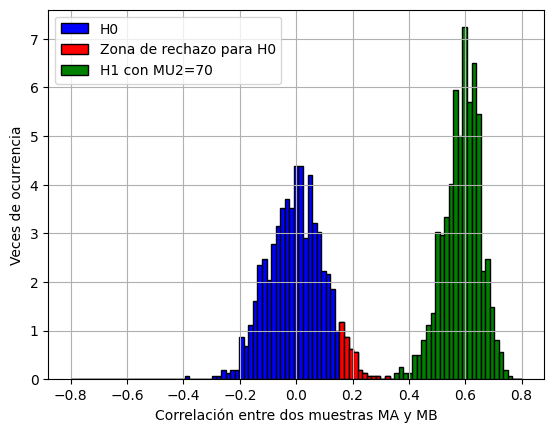

Para H1 con MU2=70, el power es  1.0 .Es decir que beta es 0.0


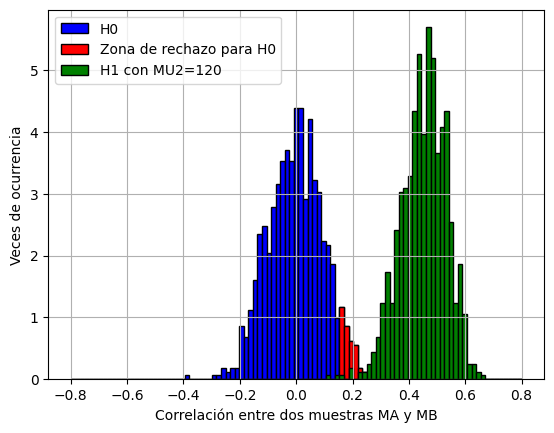

Para H1 con MU2=120, el power es  0.998 .Es decir que beta es 0.0020000000000000018


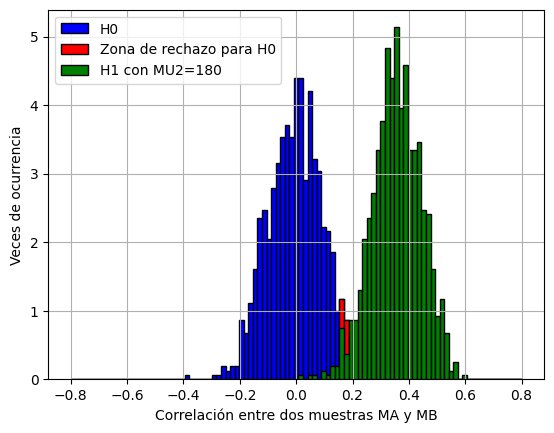

Para H1 con MU2=180, el power es  0.988 .Es decir que beta es 0.01200000000000001


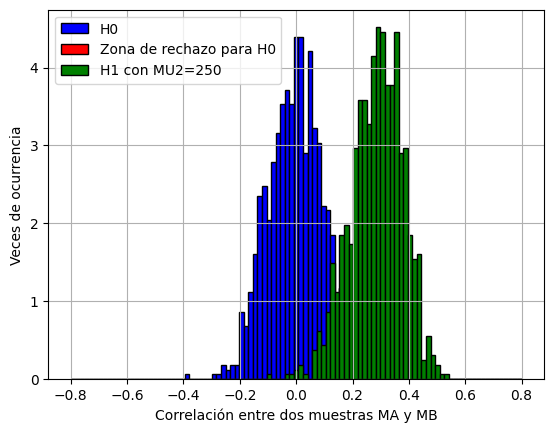

Para H1 con MU2=250, el power es  0.9120000000000001 .Es decir que beta es 0.08799999999999986


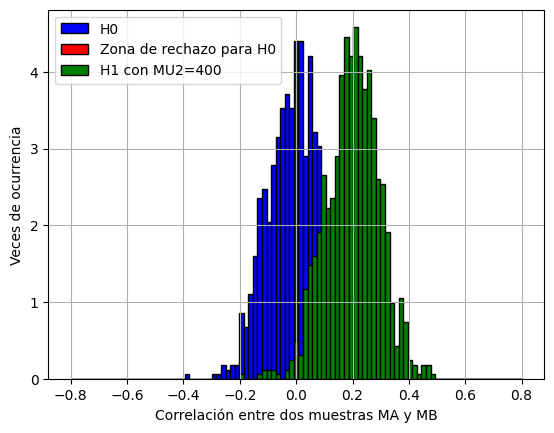

Para H1 con MU2=400, el power es  0.7080000000000001 .Es decir que beta es 0.2919999999999999


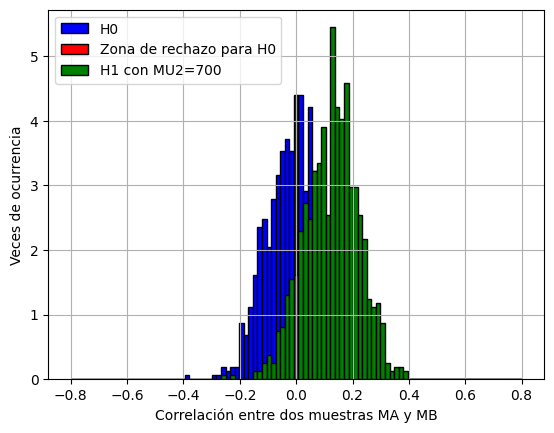

Para H1 con MU2=700, el power es  0.396 .Es decir que beta es 0.604


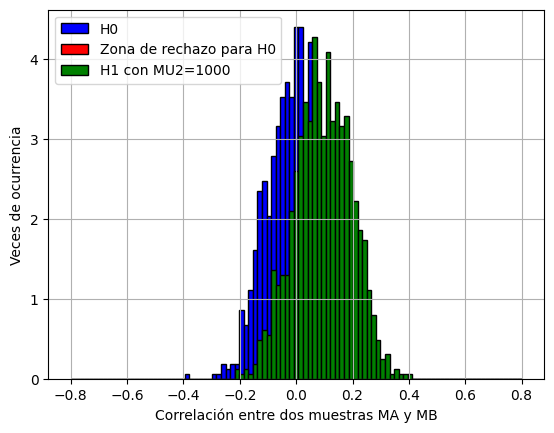

Para H1 con MU2=1000, el power es  0.29600000000000004 .Es decir que beta es 0.704


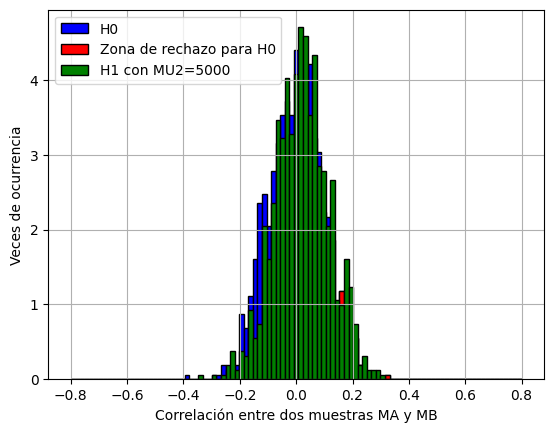

Para H1 con MU2=5000, el power es  0.08900000000000001 .Es decir que beta es 0.911


In [123]:
mu2_lista=[30,50,70,120,180,250,400,700,1000,5000]

for j in range(len(mu2_lista)):
  plt.figure()
  plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
  plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Zona de rechazo para H0')
  SA=0
  SB=0
  FA=0
  FB=0
  MA_desv=0
  MB_desv=0
  MA_bar=0
  MB_bar=0
  MA_var=0
  MB_var=0
  MA_sig=0
  MB_sig=0
  lista_cov_correlacionada=[]
  N=1000
  for i in range(N):
    SA = poisson.rvs(mu1, size=100)
    SB=SA
    FA = poisson.rvs(mu2_lista[j], size=100)
    FB = poisson.rvs(mu2_lista[j], size=100)

    MA=SA+FA
    MB=SB+FB

    MA_sig2=np.sqrt(mu1+mu2)
    MB_sig2=np.sqrt(mu1+mu2)

    MA_bar=(sum(MA))/len(MA)
    MB_bar=(sum(MB))/len(MB)

    n=len(MA)
    MA_desv=MA-MA_bar
    MB_desv=MB-MB_bar

    MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
    MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
    MA_sig=np.sqrt(MA_var)
    MB_sig=np.sqrt(MB_var)

    cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
    correlation=cov_bien/(MA_sig*MB_sig)
    lista_cov_correlacionada.append(correlation)

  bins_correlacionados = np.linspace(-0.8, 0.8, 100)
  w = np.diff(bins_correlacionados) #ANCHO DE LOS BINS
  y_density_correlacionada,Bins_correlacionados = np.histogram(lista_cov_correlacionada, bins=bins, density=True)



  #Ahora para los errore tipo 2,
  limite_inferior = Bins[sumar_hasta_valor_derecha(lista, valor_especifico)[1]]
  limite_superior = 1
  indice_inferior = np.searchsorted(Bins, limite_inferior)
  indice_superior = np.searchsorted(Bins, limite_superior)
  area_correlacionada = np.sum(y_density_correlacionada[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])

  plt.bar(Bins_correlacionados[:-1], y_density_correlacionada,width=w, color='green',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'H1 con MU2={mu2_lista[j]}') #
  plt.legend()
  plt.xlabel('Correlación entre dos muestras MA y MB')
  plt.ylabel('Veces de ocurrencia')
  plt.grid()
  plt.show()
  print(f'Para H1 con MU2={mu2_lista[j]}, el power es ',area_correlacionada,'.Es decir que beta es',1-area_correlacionada)

Para H1 con MU2=50, el power es  1.0 .Es decir que beta es 0.0
Para H1 con MU2=70, el power es  1.0 .Es decir que beta es 0.0
Para H1 con MU2=250, el power es  0.9200000000000002 .Es decir que beta es 0.07999999999999985
Para H1 con MU2=120, el power es  1.0 .Es decir que beta es 0.0


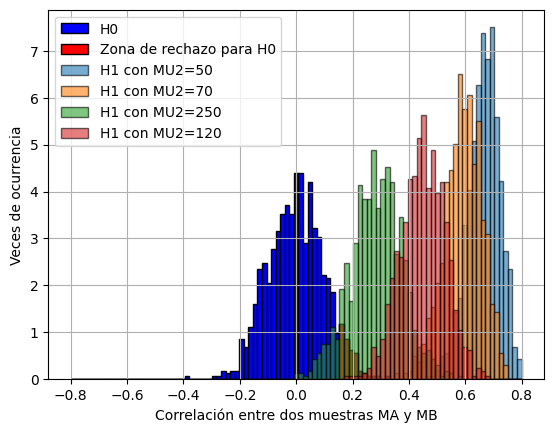

In [124]:
#Analogo al bloque anteiror solo que de aqui quiero sacar las imagenes todas juntas
mu2_lista=[50,70,250,120]
plt.figure()
plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Zona de rechazo para H0')
plt.grid()
for j in range(len(mu2_lista)):

  SA=0
  SB=0
  FA=0
  FB=0
  MA_desv=0
  MB_desv=0
  MA_bar=0
  MB_bar=0
  MA_var=0
  MB_var=0
  MA_sig=0
  MB_sig=0
  lista_cov_correlacionada=[]
  N=1000
  for i in range(N):
    SA = poisson.rvs(mu1, size=100)
    SB=SA
    FA = poisson.rvs(mu2_lista[j], size=100)
    FB = poisson.rvs(mu2_lista[j], size=100)

    MA=SA+FA
    MB=SB+FB

    MA_sig2=np.sqrt(mu1+mu2)
    MB_sig2=np.sqrt(mu1+mu2)

    MA_bar=(sum(MA))/len(MA)
    MB_bar=(sum(MB))/len(MB)

    n=len(MA)
    MA_desv=MA-MA_bar
    MB_desv=MB-MB_bar

    MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
    MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
    MA_sig=np.sqrt(MA_var)
    MB_sig=np.sqrt(MB_var)

    cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
    correlation=cov_bien/(MA_sig*MB_sig)
    lista_cov_correlacionada.append(correlation)

  bins_correlacionados = np.linspace(-0.8, 0.8, 100)
  w = np.diff(bins_correlacionados) #ANCHO DE LOS BINS
  y_density_correlacionada,Bins_correlacionados = np.histogram(lista_cov_correlacionada, bins=bins, density=True)



  #Ahora para los errore tipo 2,
  limite_inferior = Bins[sumar_hasta_valor_derecha(lista, valor_especifico)[1]]
  limite_superior = 1
  indice_inferior = np.searchsorted(Bins, limite_inferior)
  indice_superior = np.searchsorted(Bins, limite_superior)
  area_correlacionada = np.sum(y_density_correlacionada[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])

  plt.bar(Bins_correlacionados[:-1], y_density_correlacionada,width=w,align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'H1 con MU2={mu2_lista[j]}',alpha=0.6) #
  plt.legend()
  plt.xlabel('Correlación entre dos muestras MA y MB')
  plt.ylabel('Veces de ocurrencia')
  print(f'Para H1 con MU2={mu2_lista[j]}, el power es ',area_correlacionada,'.Es decir que beta es',1-area_correlacionada)

Para H1 con MU2=5000, el power es  0.09 .Es decir que beta es 0.91


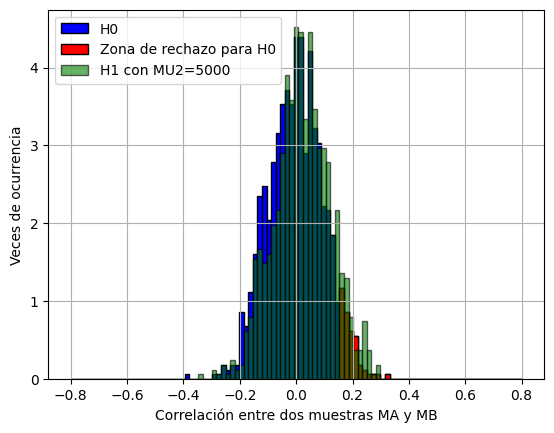

In [125]:
#Analogo al bloque anteiror solo que de aqui quiero sacar las imagenes todas juntas
mu2_lista=[5000]
plt.figure()
plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Zona de rechazo para H0')
plt.grid()
for j in range(len(mu2_lista)):

  SA=0
  SB=0
  FA=0
  FB=0
  MA_desv=0
  MB_desv=0
  MA_bar=0
  MB_bar=0
  MA_var=0
  MB_var=0
  MA_sig=0
  MB_sig=0
  lista_cov_correlacionada=[]
  N=1000
  for i in range(N):
    SA = poisson.rvs(mu1, size=100)
    SB=SA
    FA = poisson.rvs(mu2_lista[j], size=100)
    FB = poisson.rvs(mu2_lista[j], size=100)

    MA=SA+FA
    MB=SB+FB

    MA_sig2=np.sqrt(mu1+mu2)
    MB_sig2=np.sqrt(mu1+mu2)

    MA_bar=(sum(MA))/len(MA)
    MB_bar=(sum(MB))/len(MB)

    n=len(MA)
    MA_desv=MA-MA_bar
    MB_desv=MB-MB_bar

    MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
    MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
    MA_sig=np.sqrt(MA_var)
    MB_sig=np.sqrt(MB_var)

    cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
    correlation=cov_bien/(MA_sig*MB_sig)
    lista_cov_correlacionada.append(correlation)

  bins_correlacionados = np.linspace(-0.8, 0.8, 100)
  w = np.diff(bins_correlacionados) #ANCHO DE LOS BINS
  y_density_correlacionada,Bins_correlacionados = np.histogram(lista_cov_correlacionada, bins=bins, density=True)



  #Ahora para los errore tipo 2,
  limite_inferior = Bins[sumar_hasta_valor_derecha(lista, valor_especifico)[1]]
  limite_superior = 1
  indice_inferior = np.searchsorted(Bins, limite_inferior)
  indice_superior = np.searchsorted(Bins, limite_superior)
  area_correlacionada = np.sum(y_density_correlacionada[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])

  plt.bar(Bins_correlacionados[:-1], y_density_correlacionada,width=w,color='green',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'H1 con MU2={mu2_lista[j]}',alpha=0.6) #
  plt.legend()
  plt.xlabel('Correlación entre dos muestras MA y MB')
  plt.ylabel('Veces de ocurrencia')
  print(f'Para H1 con MU2={mu2_lista[j]}, el power es ',area_correlacionada,'.Es decir que beta es',1-area_correlacionada)

#Inciso 8

In [126]:

SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov_correlacionada=[]
N=1
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB=SA
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  lista_cov_correlacionada.append(correlation)


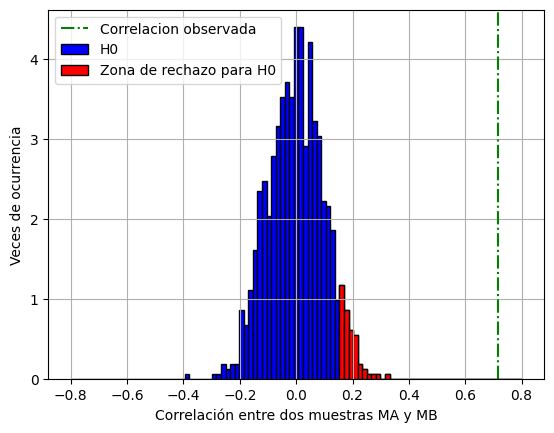

In [127]:
plt.figure()
plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Zona de rechazo para H0')
plt.axvline(lista_cov_correlacionada[0],color='green',label='Correlacion observada',linestyle='-.')
plt.grid()
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.legend()

In [128]:
#p-valor
limite_inferior = lista_cov_correlacionada[0]
limite_superior = 1
indice_inferior = np.searchsorted(Bins, limite_inferior)
indice_superior = np.searchsorted(Bins, limite_superior)
p_valor = np.sum(y_density_HO[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])

print('El p-valor para la observacion es',p_valor)

El p-valor para la observacion es 0.0


#Inciso 9

In [129]:

SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_p_valor=[]
N=1000
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB=SA
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)

  limite_inferior = correlation
  limite_superior = 1
  indice_inferior = np.searchsorted(Bins, limite_inferior)
  indice_superior = np.searchsorted(Bins, limite_superior)


  p_valor = np.sum(y_density_HO[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])
  lista_p_valor.append(p_valor)

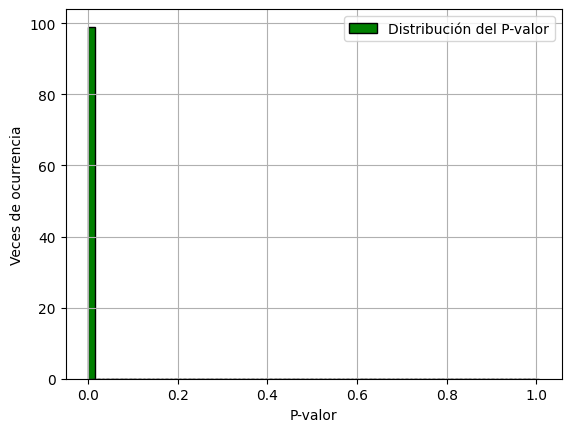

In [130]:
#Gerar el histrograma
bins_p_valor = np.linspace(0,1, 100)
w = np.diff(bins) #ANCHO DE LOS BINS
y_density_p_valor,Bins_p_valor = np.histogram(lista_p_valor, bins=bins_p_valor, density=True)
plt.bar(Bins_p_valor[:-1], y_density_p_valor,width=w, color='green',align='edge' , ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Distribución del P-valor') #
plt.grid()
plt.xlabel('P-valor')
plt.ylabel('Veces de ocurrencia')
plt.legend()

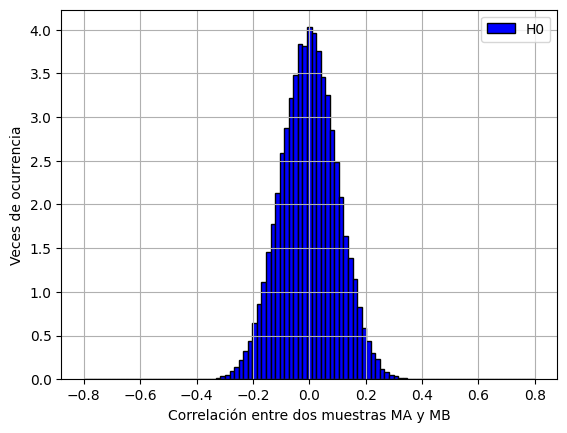

In [ ]:
#MAS REPETICIONES
#Todo junto, con variables no correlacionadas HO  ESTE SERIA EL INCISO 3
SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov=[]
N=50000
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB = poisson.rvs(mu1, size=100)
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  lista_cov.append(correlation)

bins = np.linspace(-0.8, 0.8, 100)
w = np.diff(bins) #ANCHO DE LOS BINS
y_density_HO_2,Bins_2 = np.histogram(lista_cov, bins=bins, density=True)

sigma_histograma=np.sqrt(y_density_HO_2)
errores_normalizados=sigma_histograma/(sum(y_density_HO_2))


plt.bar(Bins_2[:-1], y_density_HO_2,width=w, color='blue',align='edge' , ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.legend()
plt.grid()

In [ ]:
#zona rechazo
y_density_fuera_izquierda_2 = y_density_HO_2[:sumar_hasta_valor_izquierda(lista, valor_especifico)[1]] #Cortando hasta el numero de rechazo
w_fuera_izquierda_2=w[:len(y_density_fuera_izquierda_2)]
Bins_fuera_izquierda_2=Bins[:len(y_density_fuera_izquierda_2)+1]

nuevo_array_2 = y_density_HO_2[::-1]
Corte_invertido_2=len(nuevo_array_2)-sumar_hasta_valor_derecha(lista, valor_especifico)[1]
nuevo_array_2=nuevo_array_2[:Corte_invertido_2]
y_density_fuera_derecha_2=nuevo_array_2[::-1]

w_fuera_derecha_2=w[:len(y_density_fuera_derecha_2)]

nuevo_array_2 = Bins[::-1]
Corte_invertido_2=len(nuevo_array_2)-(sumar_hasta_valor_derecha(lista, valor_especifico)[1])
nuevo_array_2=nuevo_array_2[:Corte_invertido_2]
Bins_fuera_derecha_2=nuevo_array_2[::-1]
#print(Bins_fuera_derecha[0])


In [ ]:
plt.figure()
plt.bar(Bins_2[:-1], y_density_HO_2,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.bar(Bins_fuera_derecha_2[:-1], y_density_fuera_derecha_2,width=w_fuera_derecha_2, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Zona de rechazo para H0')
plt.axvline(lista_cov_correlacionada[0],color='green',label='Correlacion observada',linestyle='-.')
plt.grid()
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.legend()

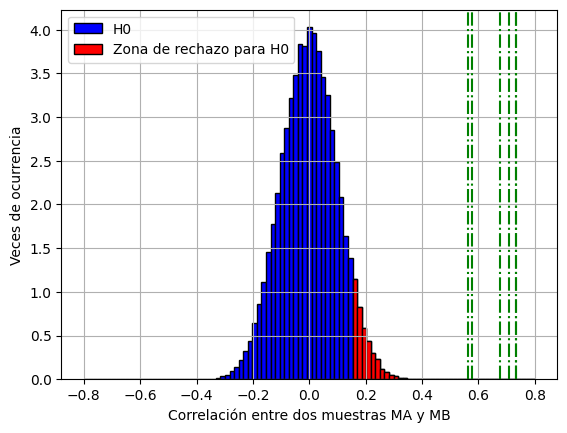

In [134]:
#Para comparar los valores observados con esta nueva distribucion H_0
plt.figure()
Bins = np.linspace(-0.8, 0.8, 100)
w = np.diff(Bins) #ANCHO DE LOS BINS
plt.bar(Bins_2[:-1], y_density_HO_2,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.bar(Bins_fuera_derecha_2[:-1], y_density_fuera_derecha_2,width=w_fuera_derecha_2, color='red',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Zona de rechazo para H0')
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.grid()
plt.legend()


SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov_correlacionada=[]
N=6
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB = SA
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  plt.axvline(correlation,color='green',label='Correlacion observada',linestyle='-.')


Para discutir que hubiese pasdao si la hipotesis nula fuese cierta, me parece util reaelizar los incisos 8 y 9 pero tomando distribuciones indepedienties, lo cual me permitiria entonces generar valores que tomen H0 como cierta

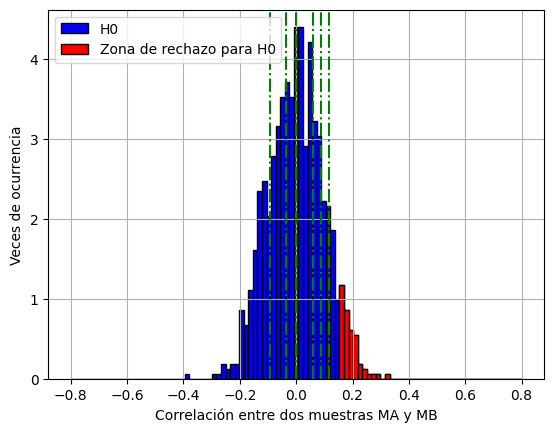

In [138]:
#Todo junto CORRELACIONADOOOO
plt.figure()
Bins = np.linspace(-0.8, 0.8, 100)
w = np.diff(Bins) #ANCHO DE LOS BINS
plt.bar(Bins[:-1], y_density_HO,width=w, color='blue',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label='H0') #
plt.bar(Bins_fuera_derecha[:-1], y_density_fuera_derecha,width=w_fuera_derecha, color='red',align='edge' , ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5)  ,label=f'Zona de rechazo para H0')
plt.xlabel('Correlación entre dos muestras MA y MB')
plt.ylabel('Veces de ocurrencia')
plt.grid()
plt.legend()


SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_cov_correlacionada=[]
N=6
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB = poisson.rvs(mu1, size=100)
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_sig2=np.sqrt(mu1+mu2)
  MB_sig2=np.sqrt(mu1+mu2)

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)
  plt.axvline(correlation,color='green',label='Correlacion observada',linestyle='-.')

AQUI SE VE DONDE CAERIAN LAS TOMAS DE VALORES RANDOMS, Y CUANTO VALDRIAN SUS P VALORES ES LA INTEGRAL DE AHI A AL IZQUIERDA

In [ ]:
#Todo junto CORRELACIONADOOOO
SA=0
SB=0
FA=0
FB=0
MA_desv=0
MB_desv=0
MA_bar=0
MB_bar=0
MA_var=0
MB_var=0
MA_sig=0
MB_sig=0
lista_p_valor=[]
N=30000
for i in range(N):
  SA = poisson.rvs(mu1, size=100)
  SB = poisson.rvs(mu1, size=100)
  FA = poisson.rvs(mu2, size=100)
  FB = poisson.rvs(mu2, size=100)

  MA=SA+FA
  MB=SB+FB

  MA_bar=(sum(MA))/len(MA)
  MB_bar=(sum(MB))/len(MB)

  n=len(MA)
  MA_desv=MA-MA_bar
  MB_desv=MB-MB_bar

  MA_var=(1/(n-1))*(sum(MA_desv*MA_desv))
  MB_var=(1/(n-1))*(sum(MB_desv*MB_desv))
  MA_sig=np.sqrt(MA_var)
  MB_sig=np.sqrt(MB_var)

  cov_bien=(1/(n-1))*(sum(MA_desv*MB_desv))
  correlation=cov_bien/(MA_sig*MB_sig)

  limite_inferior = correlation
  limite_superior = 1
  indice_inferior = np.searchsorted(bins, limite_inferior)
  indice_superior = np.searchsorted(bins, limite_superior)
  p_valor = np.sum(y_density_HO[indice_inferior:indice_superior] * np.diff(bins)[indice_inferior:indice_superior])
  lista_p_valor.append(p_valor)

In [ ]:
#Gerar el histrograma
Bins = np.linspace(0,1, 10)
w = np.diff(Bins) #ANCHO DE LOS BINS
y_density_p_valor,Bins = np.histogram(lista_p_valor, bins=Bins, density=True)

sigma_histograma=np.sqrt(y_density_p_valor)
errores_normalizados=sigma_histograma/(sum(y_density_p_valor))

plt.bar(Bins[:-1], y_density_p_valor,yerr=errores_normalizados,width=w, color='green',align='edge', ec='k',error_kw=dict(ecolor='#00C957', lw=2, capsize=2, capthick=0.5),label=f'Distribución del P-valor')
plt.grid()
plt.axhline(1,color='black',label='Distribucion uniforme',linestyle='-.')
plt.bar(0.02,1.6,width=0.04,color='red',label='Zona de rechazo',alpha=0.4)
plt.ylim(0,1.4)
plt.xlim(0,1)
plt.xlabel('P-valor')
plt.ylabel('Veces de ocurrencia')
plt.legend()